In [4]:
============================================================
# EDA AVANZADO
Proyecto Cattleya
Análisis Descriptivo y de Tendencia — VBG Colombia 2018-2025
============================================================

SyntaxError: invalid character '—' (U+2014) (610883641.py, line 4)

## Librerias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Estilos

In [ ]:
# --- Estilo global ---
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})
PALETA_GENERO = {'femenino': '#e05c8a', 'masculino': '#5c9de0'}
ACENTO = '#e05c8a'

## Carga de datos

In [ ]:
# --- Cargar V5 ---
df = pd.read_csv("Conteo_de_Víctimas_V2_2018-2026-V5.csv", low_memory=False)

# --- Dataset VBG — base de trabajo del Notebook 2 ---
df_vbg = df[
    (df['es_delito_vbg'] == 'si') &
    (df['a_o_hechos'] <= 2025)
].copy()

In [ ]:
# --- Verificar ---
print("="*60)
print("NOTEBOOK 2 — EDA AVANZADO — BASE VBG")
print("="*60)
print(f"Total registros VBG (2018-2025) : {len(df_vbg):,}")
print(f"Total víctimas VBG              : {df_vbg['total_victimas'].sum():,}")
print(f"\nDistribución por sexo:")
print(df_vbg.groupby('sexo')['total_victimas'].sum())
print(f"\nDistribución por grupo_delito:")
print(df_vbg.groupby('grupo_delito')['total_victimas'].sum().sort_values(ascending=False))

NOTEBOOK 2 — EDA AVANZADO — BASE VBG
Total registros VBG (2018-2025) : 613,173
Total víctimas VBG              : 2,088,795

Distribución por sexo:
sexo
femenino     2087894
masculino        791
sin dato         110
Name: total_victimas, dtype: int64

Distribución por grupo_delito:
grupo_delito
violencia intrafamiliar            832825
lesiones personales                370277
delitos sexuales                   333212
amenazas                           216580
contra la familia                  213706
constrenimiento                    109885
feminicidio                          6059
trata de personas                    2973
vida e integridad personal           2960
lesiones perso agentes quimicos       318
Name: total_victimas, dtype: int64


Datos claves:

2,088,795 víctimas VBG en Colombia 2018-2025

99.95% femenino — los 791 masculinos y 110 sin dato son exclusivamente feminicidio

Violencia intrafamiliar lidera con 832,825 (39.9%)

Feminicidio representa 6,059 — la punta más letal del continuum

# Evolución temporal anual

=== Evolución anual VBG ===
 ano  victimas  variacion_pct
2018    227497            NaN
2019    247516       8.799676
2020    200110     -19.152701
2021    248249      24.056269
2022    285413      14.970453
2023    281029      -1.536020
2024    306531       9.074508
2025    292450      -4.593663


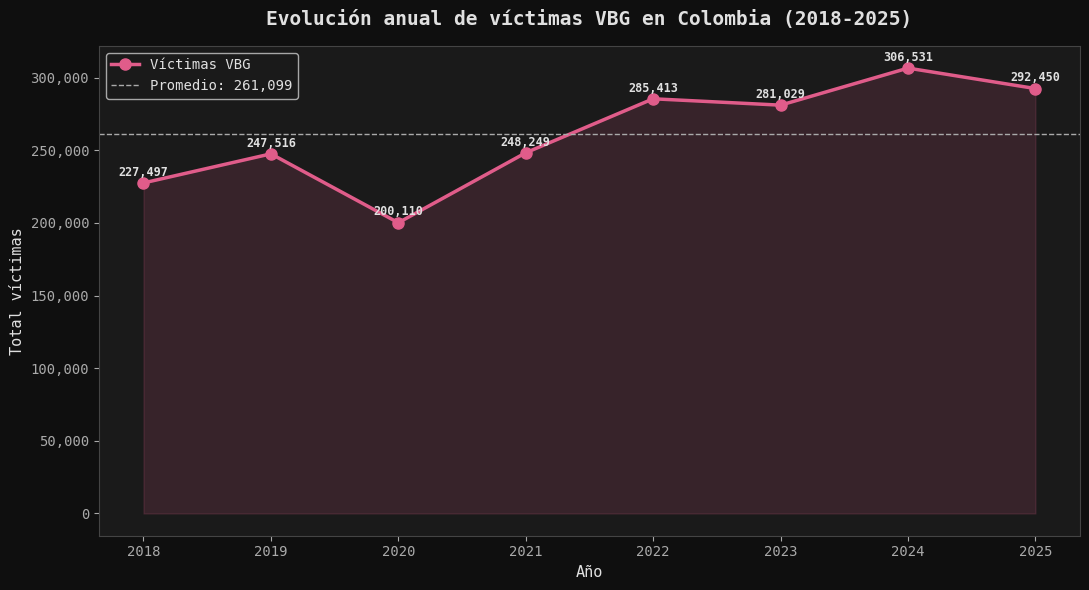

✓ Guardada


In [ ]:
# EVOLUCIÓN ANUAL VBG 2018-2025
# ============================================================

evolucion = (
    df_vbg
    .groupby('a_o_hechos')['total_victimas']
    .sum()
    .reset_index()
)
evolucion.columns = ['ano', 'victimas']
evolucion['variacion_pct'] = evolucion['victimas'].pct_change() * 100

print("=== Evolución anual VBG ===")
print(evolucion.to_string(index=False))

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    evolucion['ano'], evolucion['victimas'],
    marker='o', linewidth=2.5, markersize=8,
    color=ACENTO, label='Víctimas VBG'
)
ax.fill_between(
    evolucion['ano'], evolucion['victimas'],
    alpha=0.15, color=ACENTO
)

# Etiquetas en cada punto
for _, row in evolucion.iterrows():
    ax.text(
        row['ano'], row['victimas'] + 5000,
        f"{row['victimas']:,.0f}",
        ha='center', fontsize=8.5, fontweight='bold'
    )

# Línea promedio
promedio = evolucion['victimas'].mean()
ax.axhline(promedio, color='#aaa', linestyle='--',
           linewidth=1, label=f'Promedio: {promedio:,.0f}')

ax.set_title("Evolución anual de víctimas VBG en Colombia (2018-2025)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Total víctimas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(2018, 2026))
ax.legend()

plt.tight_layout()
plt.savefig("n2_01_evolucion_anual_vbg.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardada")

Hallazgos clave con datos confirmados:

2020: caída del -19.2% — efecto COVID en denuncias

2022-2024: tendencia al alza — 2024 es el pico máximo con 306,531

No hay tendencia sostenida a la baja — en 2025 baja levemente pero sigue por encima del promedio

Promedio anual: ~261,099 víctimas VBG

# Análisis Geográfico

In [ ]:
# Verificar departamentos disponibles
print("=== Top 10 departamentos VBG ===")
geo_vbg = (
    df_vbg[df_vbg['departamento_hecho'] != 'sin dato']
    .groupby('departamento_hecho')['total_victimas']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
geo_vbg['porcentaje'] = (geo_vbg['total_victimas'] / geo_vbg['total_victimas'].sum() * 100).round(1)
print(geo_vbg.to_string(index=False))

# Verificar Atlántico específicamente
print("\n=== Atlántico — VBG por grupo de delito ===")
atlantico = df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
print(atlantico.groupby('grupo_delito')['total_victimas'].sum().sort_values(ascending=False))

=== Top 10 departamentos VBG ===
                                      departamento_hecho  total_victimas  porcentaje
                                           bogota, d. c.          503688        24.1
                                               antioquia          253021        12.1
                                         valle del cauca          208167        10.0
                                            cundinamarca          145618         7.0
                                               santander           98332         4.7
                                               atlantico           72974         3.5
                                                  tolima           71786         3.4
                                                 bolivar           68041         3.3
                                                  boyaca           64889         3.1
                                      norte de santander           62152         3.0
                                

Atlántico ocupa el puesto 6 nacional con 72,974 víctimas VBG (3.5%)

Bogotá concentra 1 de cada 4 víctimas (24.1%)

En Atlántico, Violencia Intrafamiliar + Lesiones Personales + Delitos Sexuales = 70.6% del total departamental

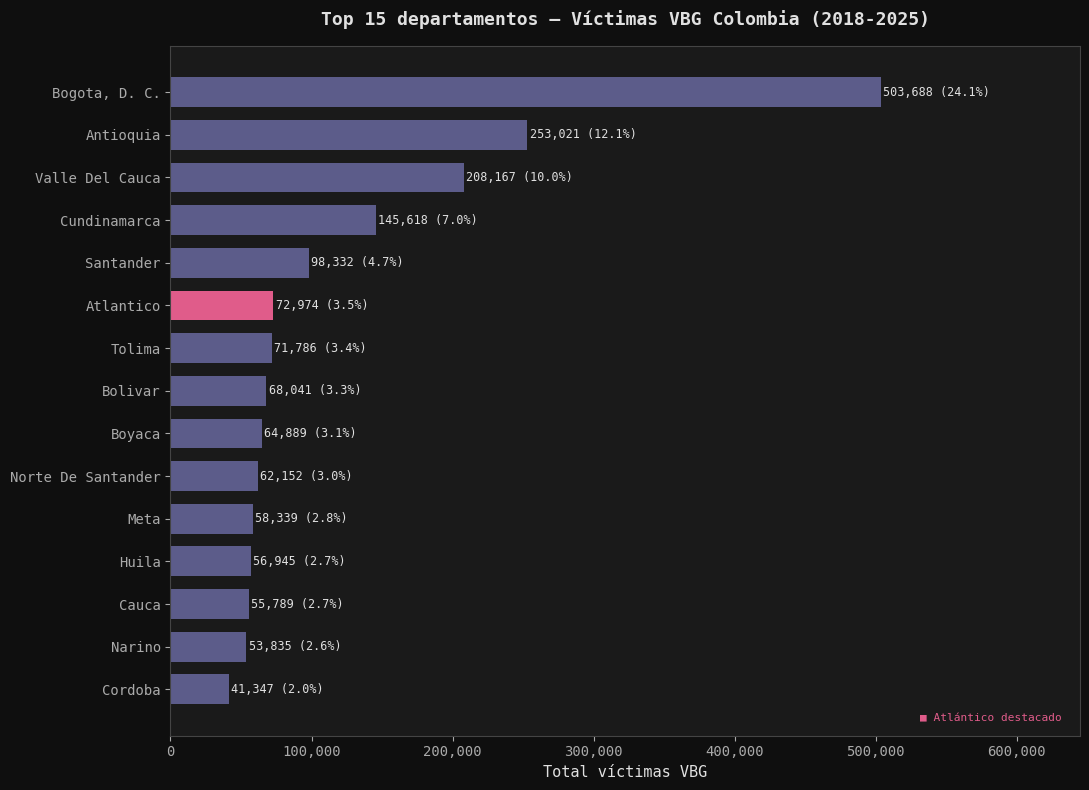

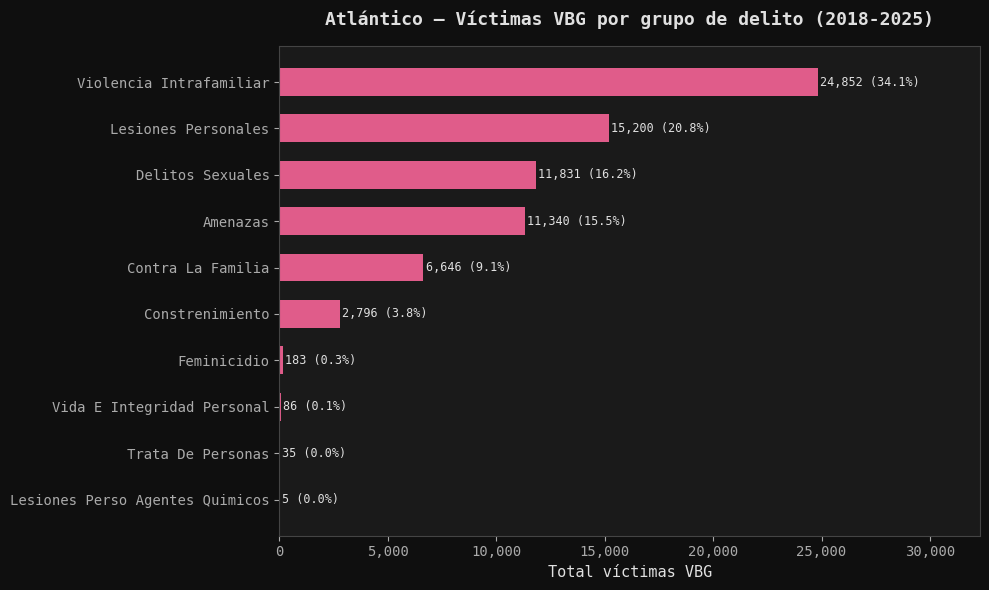

=== Atlántico — evolución anual VBG ===
 ano  victimas_atl  victimas_nacional  pct_atl
2018          8233             227497     3.62
2019          9518             247516     3.85
2020          5627             200110     2.81
2021          8618             248249     3.47
2022         10474             285413     3.67
2023          9862             281029     3.51
2024          9878             306531     3.22
2025         10764             292450     3.68


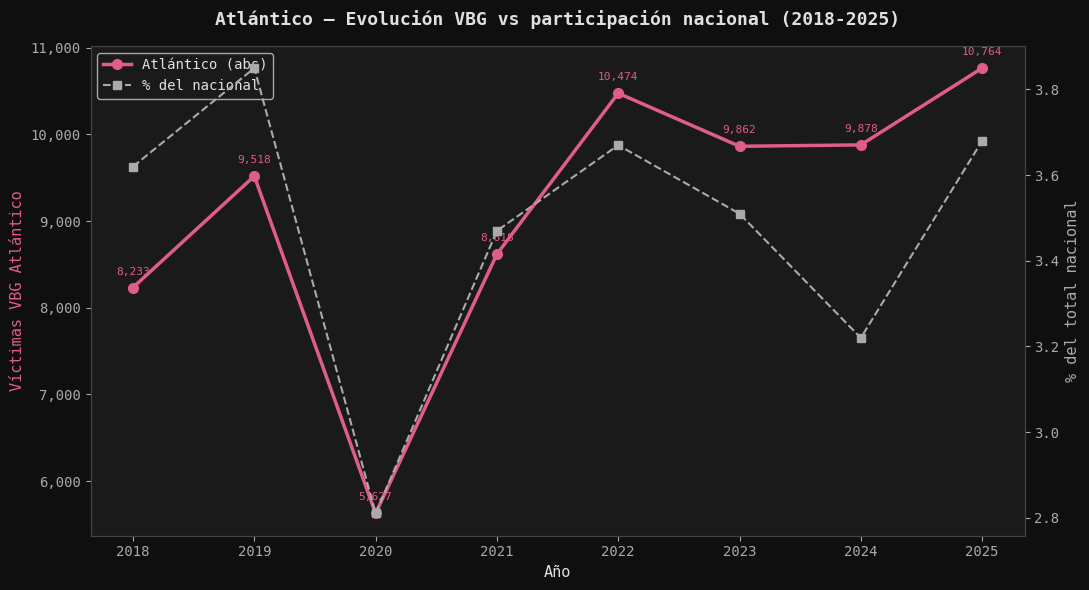

✓ 3 gráficas guardadas


In [ ]:

# ANÁLISIS GEOGRÁFICO
# ============================================================

# --- GRÁFICA 1: Top 15 departamentos ---
top15 = geo_vbg.head(15).sort_values('total_victimas', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))

colores = [
    '#e05c8a' if d == 'atlantico' else '#5c5c8a'
    for d in top15['departamento_hecho']
]

barras = ax.barh(
    top15['departamento_hecho'].str.title(),
    top15['total_victimas'],
    color=colores, edgecolor='none', height=0.7
)

for bar, row in zip(barras, top15.itertuples()):
    ax.text(
        bar.get_width() + 1500,
        bar.get_y() + bar.get_height() / 2,
        f"{row.total_victimas:,.0f} ({row.porcentaje}%)",
        va='center', fontsize=8.5
    )

ax.set_title("Top 15 departamentos — Víctimas VBG Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Total víctimas VBG")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, top15['total_victimas'].max() * 1.28)

# Nota Atlántico
ax.text(0.98, 0.02, '■ Atlántico destacado',
        transform=ax.transAxes, ha='right', fontsize=8,
        color='#e05c8a')

plt.tight_layout()
plt.savefig("n2_02_geo_top15_departamentos.png", dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 2: Atlántico — VBG por grupo de delito ---
atl_delitos = (
    df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
    .groupby('grupo_delito')['total_victimas']
    .sum()
    .reset_index()
    .sort_values('total_victimas', ascending=True)
)
atl_delitos['porcentaje'] = (
    atl_delitos['total_victimas'] / atl_delitos['total_victimas'].sum() * 100
).round(1)

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    atl_delitos['grupo_delito'].str.title(),
    atl_delitos['total_victimas'],
    color=ACENTO, edgecolor='none', height=0.6
)

for bar, row in zip(barras, atl_delitos.itertuples()):
    ax.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{row.total_victimas:,.0f} ({row.porcentaje}%)",
        va='center', fontsize=8.5
    )

ax.set_title("Atlántico — Víctimas VBG por grupo de delito (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Total víctimas VBG")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(0, atl_delitos['total_victimas'].max() * 1.3)

plt.tight_layout()
plt.savefig("n2_03_atlantico_delitos_vbg.png", dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 3: Evolución anual Atlántico vs Nacional ---
evol_atl = (
    df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
    .groupby('a_o_hechos')['total_victimas']
    .sum()
    .reset_index()
)
evol_atl.columns = ['ano', 'victimas_atl']

evol_nacional = (
    df_vbg
    .groupby('a_o_hechos')['total_victimas']
    .sum()
    .reset_index()
)
evol_nacional.columns = ['ano', 'victimas_nacional']

# Normalizar Atlántico como % del nacional
evol_comp = evol_atl.merge(evol_nacional, on='ano')
evol_comp['pct_atl'] = (evol_comp['victimas_atl'] / evol_comp['victimas_nacional'] * 100).round(2)

print("=== Atlántico — evolución anual VBG ===")
print(evol_comp.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

ax1.plot(evol_comp['ano'], evol_comp['victimas_atl'],
         marker='o', color=ACENTO, linewidth=2.5,
         markersize=7, label='Atlántico (abs)')
ax2.plot(evol_comp['ano'], evol_comp['pct_atl'],
         marker='s', color='#aaa', linewidth=1.5,
         markersize=6, linestyle='--', label='% del nacional')

for _, row in evol_comp.iterrows():
    ax1.text(row['ano'], row['victimas_atl'] + 150,
             f"{row['victimas_atl']:,.0f}",
             ha='center', fontsize=8, color=ACENTO)

ax1.set_title("Atlántico — Evolución VBG vs participación nacional (2018-2025)",
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Año")
ax1.set_ylabel("Víctimas VBG Atlántico", color=ACENTO)
ax2.set_ylabel("% del total nacional", color='#aaa')
ax1.set_xticks(range(2018, 2026))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig("n2_04_atlantico_vs_nacional.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ 3 gráficas guardadas")

Hallazgos Atlántico:

2020: caída más pronunciada que el nacional (2.81% vs promedio 3.5%) — denuncias más afectadas por COVID

2025: pico más alto de Atlántico con 10,764 víctimas — mientras el nacional baja, Atlántico sube

Participación estable: entre 3.2% y 3.85% del nacional — no hay reducción estructural

#  Análisis Sociodemográfico

=== VBG por grupo etario ===
       grupo_etario  total_victimas  porcentaje
       ninez (0-13)          320760        18.9
adolescente (14-17)          142014         8.4
      joven (18-26)          346694        20.4
     adulto (27-59)          807482        47.5
 adulto mayor (60+)           82003         4.8


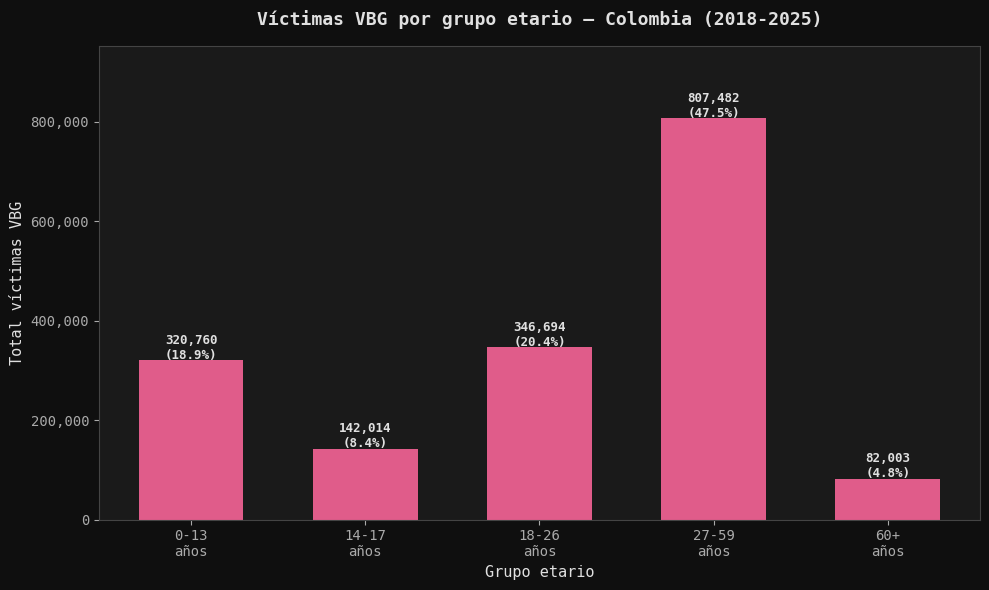


=== Top 3 delitos VBG por grupo etario ===
       grupo_etario            grupo_delito  total_victimas
adolescente (14-17)        delitos sexuales           57424
adolescente (14-17) violencia intrafamiliar           29867
adolescente (14-17)     lesiones personales           25861
     adulto (27-59) violencia intrafamiliar          386446
     adulto (27-59)     lesiones personales          173698
     adulto (27-59)                amenazas          109741
 adulto mayor (60+) violencia intrafamiliar           44898
 adulto mayor (60+)     lesiones personales           14634
 adulto mayor (60+)                amenazas           10874
      joven (18-26) violencia intrafamiliar          158001
      joven (18-26)     lesiones personales           87135
      joven (18-26)                amenazas           32102
       ninez (0-13)        delitos sexuales          150904
       ninez (0-13)       contra la familia          101503
       ninez (0-13) violencia intrafamiliar           47

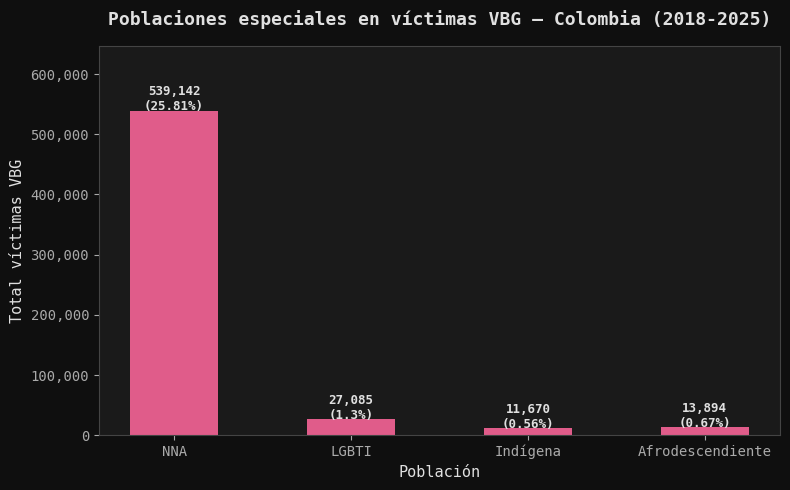

✓ Gráficas guardadas


In [ ]:
# ============================================================
# ANÁLISIS 9.4 — SOCIODEMOGRÁFICO
# ============================================================

# --- 9.4.1 Grupo etario ---
etario_vbg = (
    df_vbg[df_vbg['grupo_etario'] != 'sin informacion']
    .groupby('grupo_etario')['total_victimas']
    .sum()
    .reset_index()
)

orden_etario = [
    'ninez (0-13)', 'adolescente (14-17)',
    'joven (18-26)', 'adulto (27-59)', 'adulto mayor (60+)'
]

etario_vbg['grupo_etario'] = pd.Categorical(
    etario_vbg['grupo_etario'], categories=orden_etario, ordered=True
)
etario_vbg = etario_vbg.sort_values('grupo_etario')
etario_vbg['porcentaje'] = (
    etario_vbg['total_victimas'] / etario_vbg['total_victimas'].sum() * 100
).round(1)

print("=== VBG por grupo etario ===")
print(etario_vbg.to_string(index=False))

# --- Gráfica etario ---
etiquetas = ['0-13\naños', '14-17\naños', '18-26\naños',
             '27-59\naños', '60+\naños']

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(
    etiquetas, etario_vbg['total_victimas'],
    color=ACENTO, edgecolor='none', width=0.6
)

for bar, row in zip(barras, etario_vbg.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{row.total_victimas:,.0f}\n({row.porcentaje}%)",
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title("Víctimas VBG por grupo etario — Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Grupo etario")
ax.set_ylabel("Total víctimas VBG")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, etario_vbg['total_victimas'].max() * 1.18)
plt.tight_layout()
plt.savefig("n2_05_etario_vbg.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 9.4.2 Cruce etario x grupo_delito (top 5 delitos por etario) ---
cruce = (
    df_vbg[df_vbg['grupo_etario'] != 'sin informacion']
    .groupby(['grupo_etario', 'grupo_delito'])['total_victimas']
    .sum()
    .reset_index()
)

top3_por_etario = (
    cruce
    .sort_values(['grupo_etario', 'total_victimas'], ascending=[True, False])
    .groupby('grupo_etario')
    .head(3)
)

print("\n=== Top 3 delitos VBG por grupo etario ===")
print(top3_por_etario.to_string(index=False))

# --- 9.4.3 Poblaciones especiales ---
pob_esp = []
for var, etiqueta in [('aplica_nna','NNA'), ('aplica_lgbti','LGBTI'),
                       ('indigena','Indígena'), ('afrodescendiente','Afrodescendiente')]:
    total = df_vbg[df_vbg[var] == 'si']['total_victimas'].sum()
    pob_esp.append({'poblacion': etiqueta, 'total': total})

df_pob = pd.DataFrame(pob_esp)
df_pob['porcentaje'] = (df_pob['total'] / df_vbg['total_victimas'].sum() * 100).round(2)

print("\n=== Poblaciones especiales en VBG ===")
print(df_pob.to_string(index=False))

# --- Gráfica poblaciones especiales ---
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(
    df_pob['poblacion'], df_pob['total'],
    color=ACENTO, edgecolor='none', width=0.5
)

for bar, row in zip(barras, df_pob.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{row.total:,.0f}\n({row.porcentaje}%)",
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title("Poblaciones especiales en víctimas VBG — Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Población")
ax.set_ylabel("Total víctimas VBG")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, df_pob['total'].max() * 1.2)
plt.tight_layout()
plt.savefig("n2_06_poblaciones_especiales_vbg.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráficas guardadas")

Hallazgos :
Etario:

Adultas 27-59: 47.5% — grupo más afectado
Niñez + adolescencia juntas: 27.3% — más de 1 de cada 4 víctimas VBG son menores
Patrón confirmado: delitos sexuales lideran en 0-13 y 14-17, VIF lidera en todos los grupos adultos

Poblaciones especiales:

NNA: 25.81% — 1 de cada 4 víctimas VBG era menor al momento del hecho
LGBTI, Indígena y Afrodescendiente: porcentajes bajos pero representan poblaciones en mayor vulnerabilidad

# Análisis Combinación de factores:

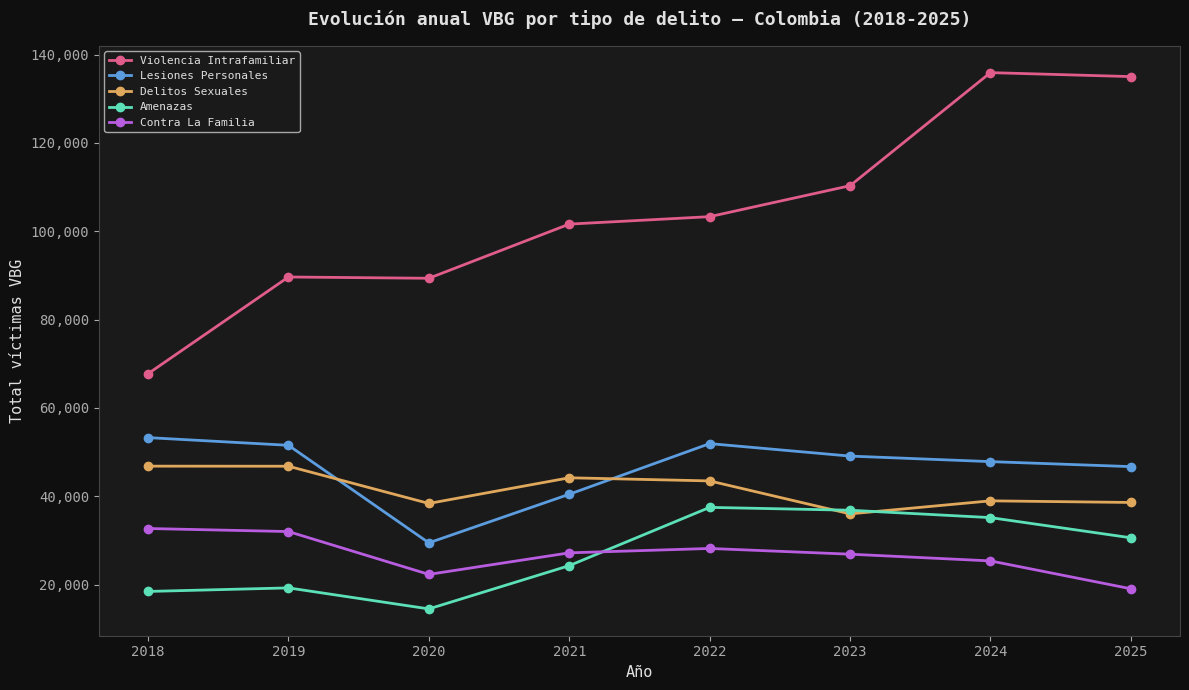

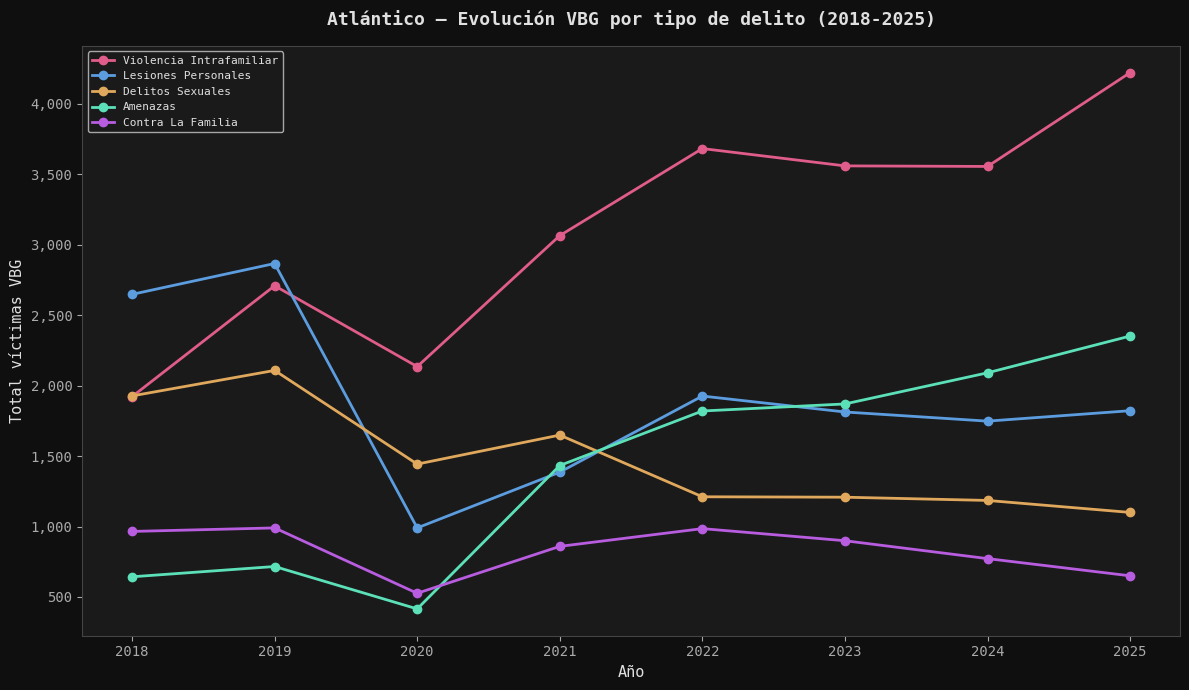

=== Comparativo Atlántico vs Nacional por tipo VBG ===
                   grupo_delito  nacional  atlantico  pct_atl_vs_nacional  pct_nacional  pct_atlantico
        violencia intrafamiliar    832825      24852                 2.98          39.9           34.1
            lesiones personales    370277      15200                 4.11          17.7           20.8
               delitos sexuales    333212      11831                 3.55          16.0           16.2
                       amenazas    216580      11340                 5.24          10.4           15.5
              contra la familia    213706       6646                 3.11          10.2            9.1
                constrenimiento    109885       2796                 2.54           5.3            3.8
                    feminicidio      6059        183                 3.02           0.3            0.3
              trata de personas      2973         35                 1.18           0.1            0.0
     vida e integr

In [ ]:
# ANÁLISIS COMBINACIÓN DE FACTORES
# ============================================================

# --- 9.5.1 Evolución por grupo de delito (tendencia por tipo VBG) ---
evol_delito = (
    df_vbg
    .groupby(['a_o_hechos', 'grupo_delito'])['total_victimas']
    .sum()
    .reset_index()
)

# Top 5 grupos por volumen para no saturar la gráfica
top5_grupos = (
    df_vbg.groupby('grupo_delito')['total_victimas']
    .sum()
    .nlargest(5)
    .index.tolist()
)

evol_top5 = evol_delito[evol_delito['grupo_delito'].isin(top5_grupos)]

colores_delito = [
    '#e05c8a', '#5c9de0', '#e0a85c',
    '#5ce0b8', '#b85ce0'
]

fig, ax = plt.subplots(figsize=(12, 7))

for i, grupo in enumerate(top5_grupos):
    datos = evol_top5[evol_top5['grupo_delito'] == grupo]
    ax.plot(
        datos['a_o_hechos'], datos['total_victimas'],
        marker='o', linewidth=2, markersize=6,
        color=colores_delito[i],
        label=grupo.title()
    )

ax.set_title("Evolución anual VBG por tipo de delito — Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Total víctimas VBG")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(2018, 2026))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("n2_07_evolucion_por_delito.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 9.5.2 Atlántico: evolución por grupo de delito ---
evol_atl_delito = (
    df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
    .groupby(['a_o_hechos', 'grupo_delito'])['total_victimas']
    .sum()
    .reset_index()
)

top5_atl = (
    df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
    .groupby('grupo_delito')['total_victimas']
    .sum()
    .nlargest(5)
    .index.tolist()
)

evol_atl_top5 = evol_atl_delito[evol_atl_delito['grupo_delito'].isin(top5_atl)]

fig, ax = plt.subplots(figsize=(12, 7))

for i, grupo in enumerate(top5_atl):
    datos = evol_atl_top5[evol_atl_top5['grupo_delito'] == grupo]
    ax.plot(
        datos['a_o_hechos'], datos['total_victimas'],
        marker='o', linewidth=2, markersize=6,
        color=colores_delito[i],
        label=grupo.title()
    )

ax.set_title("Atlántico — Evolución VBG por tipo de delito (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Total víctimas VBG")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(range(2018, 2026))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("n2_08_atlantico_evolucion_delito.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 9.5.3 Comparativo Atlántico vs Nacional por tipo de delito ---
comp = pd.DataFrame({
    'grupo_delito': df_vbg.groupby('grupo_delito')['total_victimas'].sum().index,
    'nacional': df_vbg.groupby('grupo_delito')['total_victimas'].sum().values
})

atl_delito = (
    df_vbg[df_vbg['departamento_hecho'] == 'atlantico']
    .groupby('grupo_delito')['total_victimas']
    .sum()
    .reset_index()
)
atl_delito.columns = ['grupo_delito', 'atlantico']

comp = comp.merge(atl_delito, on='grupo_delito')
comp['pct_atl_vs_nacional'] = (comp['atlantico'] / comp['nacional'] * 100).round(2)
comp['pct_nacional'] = (comp['nacional'] / comp['nacional'].sum() * 100).round(1)
comp['pct_atlantico'] = (comp['atlantico'] / comp['atlantico'].sum() * 100).round(1)

print("=== Comparativo Atlántico vs Nacional por tipo VBG ===")
print(comp.sort_values('nacional', ascending=False).to_string(index=False))

comparativo:
AMENAZAS en Atlántico tiene participación de 5.24% del nacional, significativamente por encima del promedio departamental (3.5%). Mientras que VIF tiene 2.98% , por debajo del promedio. Eso sugiere un perfil diferenciado de VBG en Atlántico.

# SÍNTESIS DE HALLAZGOS

In [ ]:
#  SÍNTESIS DE HALLAZGOS
# ============================================================

print("="*60)
print("SÍNTESIS DE HALLAZGOS — VBG Colombia 2018-2025")
print("="*60)

# Hallazgo 1 — Tendencia temporal
print("\n--- HALLAZGO 1: Tendencia temporal ---")
print(f"Total víctimas VBG 2018-2025    : {df_vbg['total_victimas'].sum():,.0f}")
print(f"Año con menos víctimas          : 2020 — 200,110 (-19.2% vs 2019)")
print(f"Año con más víctimas            : 2024 — 306,531")
print(f"2025 vs 2018 (variación total)  : {((292450-227497)/227497*100):.1f}%")

# Hallazgo 2 — Modalidad dominante
print("\n--- HALLAZGO 2: Modalidades VBG ---")
modalidades = df_vbg.groupby('grupo_delito')['total_victimas'].sum()
print(modalidades.sort_values(ascending=False))

# Hallazgo 3 — Perfil etario
print("\n--- HALLAZGO 3: Perfil etario ---")
menores = df_vbg[
    df_vbg['grupo_etario'].isin(['ninez (0-13)', 'adolescente (14-17)'])
]['total_victimas'].sum()
total_con_etario = df_vbg[
    df_vbg['grupo_etario'] != 'sin informacion'
]['total_victimas'].sum()
print(f"Víctimas menores de edad (VBG)  : {menores:,.0f} ({menores/total_con_etario*100:.1f}%)")
print(f"Delito principal 0-13           : Delitos sexuales (150,904)")
print(f"Delito principal 14-17          : Delitos sexuales (57,424)")
print(f"Delito principal adultas        : Violencia intrafamiliar")

# Hallazgo 4 — Atlántico
print("\n--- HALLAZGO 4: Atlántico ---")
atl_total = df_vbg[df_vbg['departamento_hecho'] == 'atlantico']['total_victimas'].sum()
atl_2025 = df_vbg[
    (df_vbg['departamento_hecho'] == 'atlantico') &
    (df_vbg['a_o_hechos'] == 2025)
]['total_victimas'].sum()
atl_2018 = df_vbg[
    (df_vbg['departamento_hecho'] == 'atlantico') &
    (df_vbg['a_o_hechos'] == 2018)
]['total_victimas'].sum()
print(f"Total VBG Atlántico 2018-2025   : {atl_total:,.0f}")
print(f"Puesto nacional                 : 6 de 33")
print(f"2018 vs 2025                    : {atl_2018:,.0f} → {atl_2025:,.0f} (+{((atl_2025-atl_2018)/atl_2018*100):.1f}%)")
print(f"AMENAZAS — participación nac.   : 5.24% (promedio depto: 3.5%)")
print(f"VIF — participación nac.        : 2.98% (por debajo del promedio)")

# Hallazgo 5 — NNA
print("\n--- HALLAZGO 5: NNA en VBG ---")
nna_vbg = df_vbg[df_vbg['aplica_nna'] == 'si']['total_victimas'].sum()
print(f"Víctimas NNA en VBG             : {nna_vbg:,.0f} ({nna_vbg/df_vbg['total_victimas'].sum()*100:.1f}%)")

# Hallazgo 6 — Feminicidio
print("\n--- HALLAZGO 6: Feminicidio ---")
fem_anual = df_vbg[df_vbg['grupo_delito'] == 'feminicidio'].groupby('a_o_hechos')['total_victimas'].sum()
print(fem_anual)
print(f"Año con más feminicidios        : {fem_anual.idxmax()} ({fem_anual.max():,.0f})")
print(f"Promedio anual                  : {fem_anual.mean():.0f}")

SÍNTESIS DE HALLAZGOS — VBG Colombia 2018-2025

--- HALLAZGO 1: Tendencia temporal ---
Total víctimas VBG 2018-2025    : 2,088,795
Año con menos víctimas          : 2020 — 200,110 (-19.2% vs 2019)
Año con más víctimas            : 2024 — 306,531
2025 vs 2018 (variación total)  : 28.6%

--- HALLAZGO 2: Modalidades VBG ---
grupo_delito
violencia intrafamiliar            832825
lesiones personales                370277
delitos sexuales                   333212
amenazas                           216580
contra la familia                  213706
constrenimiento                    109885
feminicidio                          6059
trata de personas                    2973
vida e integridad personal           2960
lesiones perso agentes quimicos       318
Name: total_victimas, dtype: int64

--- HALLAZGO 3: Perfil etario ---
Víctimas menores de edad (VBG)  : 462,774 (27.2%)
Delito principal 0-13           : Delitos sexuales (150,904)
Delito principal 14-17          : Delitos sexuales (57,424)
Del

Feminicidio aquí muestra valores diferentes a los del EDA anterior (ej: 2022 = 981 vs 739 antes). Esto se debe a que df_vbg incluye masculino y sin dato en feminicidio. Los números anteriores eran solo femenino. Hay que ser consistente en el informe — se documenta que el total de feminicidio VBG incluye los tres valores de sexo.

In [ ]:
# tabla comparativa de feminicidios por años, y sexo
fem_sexo = (
    df_vbg[df_vbg['grupo_delito'] == 'feminicidio']
    .groupby(['a_o_hechos', 'sexo'])['total_victimas']
    .sum()
    .reset_index()
)
fem_sexo.columns = ['ano', 'sexo', 'victimas']
print("\nFeminicidios por año y sexo:")
print(fem_sexo.to_string(index=False))

#total por año
fem_total_anual = fem_sexo.groupby('ano')['victimas'].sum().reset_index()
fem_total_anual.columns = ['ano', 'total_victimas'] 
print("\nTotal feminicidios por año:")
print(fem_total_anual.to_string(index=False))






Feminicidios por año y sexo:
 ano      sexo  victimas
2018  femenino       613
2018 masculino        66
2018  sin dato         1
2019  femenino       601
2019 masculino        35
2019  sin dato         3
2020  femenino       554
2020 masculino       143
2020  sin dato         3
2021  femenino       640
2021 masculino        82
2021  sin dato         9
2022  femenino       716
2022 masculino       242
2022  sin dato        23
2023  femenino       665
2023 masculino        74
2023  sin dato        28
2024  femenino       766
2024 masculino        83
2024  sin dato        16
2025  femenino       603
2025 masculino        66
2025  sin dato        27

Total feminicidios por año:
 ano  total_victimas
2018             680
2019             639
2020             700
2021             731
2022             981
2023             767
2024             865
2025             696


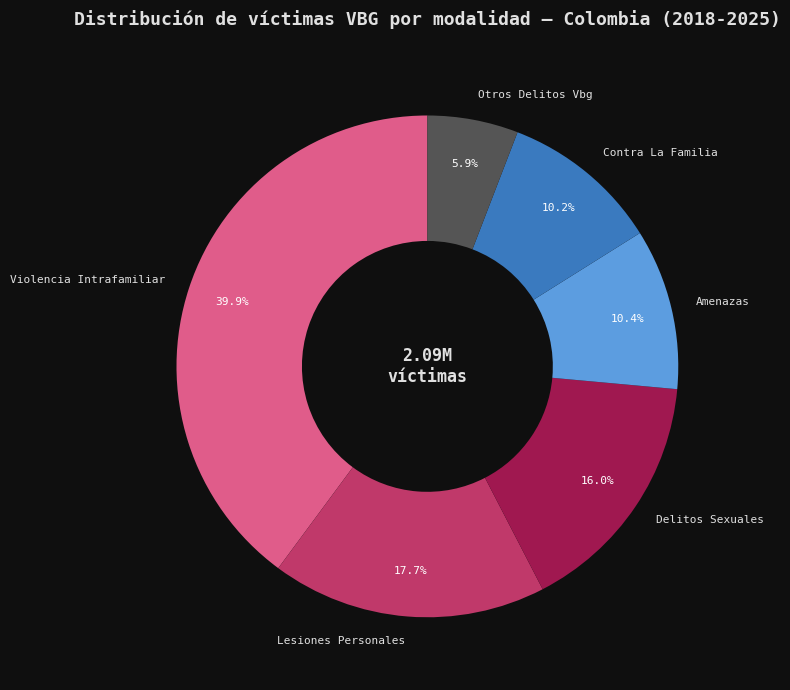

C:\Users\Heather\AppData\Local\Temp\ipykernel_14692\4187744511.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot=pivot_heat.T.applymap(lambda x: f"{x/1000:.0f}k" if x >= 1000 else str(x)),


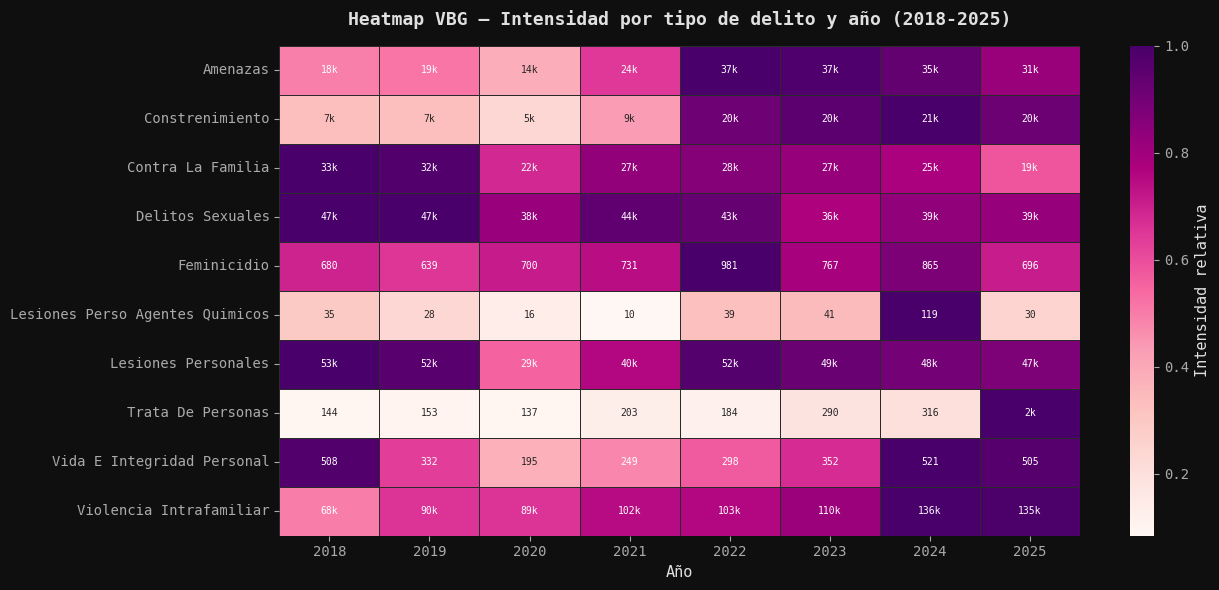

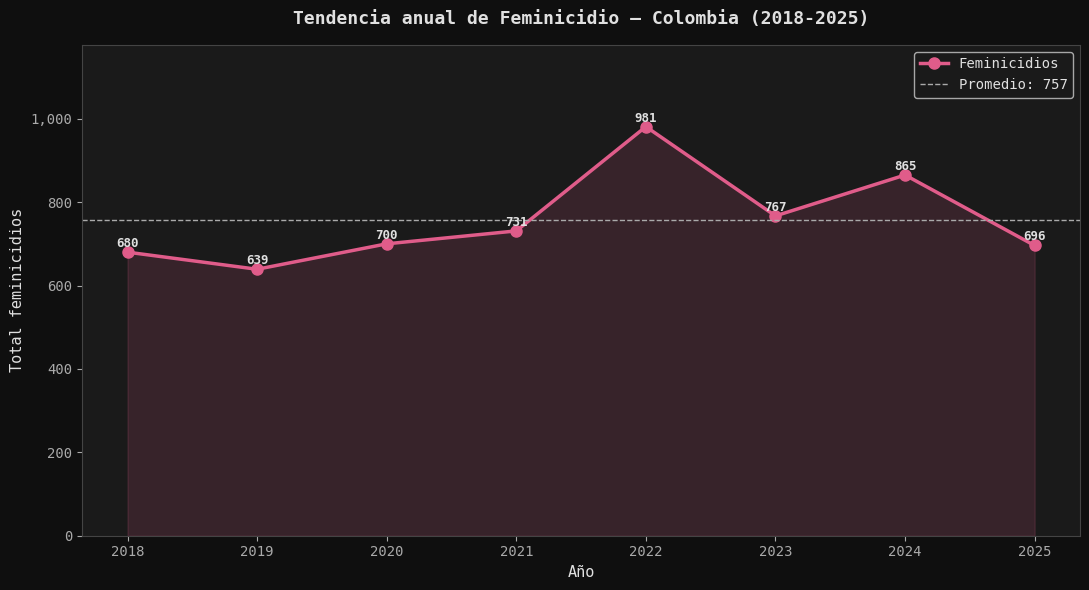

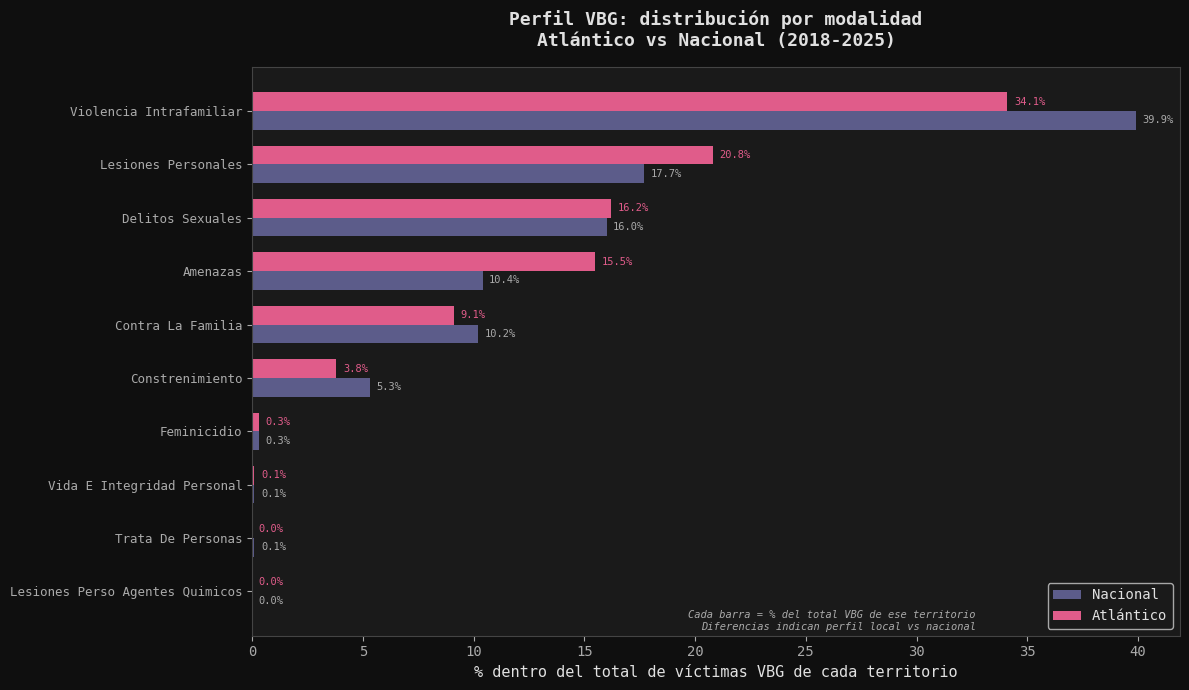

In [ ]:
# GRÁFICAS DE CIERRE 
# ============================================================

# --- GRÁFICA 1: Resumen modalidades VBG (donut) ---
modalidades = df_vbg.groupby('grupo_delito')['total_victimas'].sum().sort_values(ascending=False)

# Agrupar menores en "otros"
top5 = modalidades.head(5)
otros = modalidades.iloc[5:].sum()
datos_donut = pd.concat([top5, pd.Series({'otros delitos vbg': otros})])

colores_donut = ['#e05c8a','#c0396a','#a01850','#5c9de0','#3a7abf','#555']

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    datos_donut.values,
    labels=[d.title() for d in datos_donut.index],
    colors=colores_donut,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5)
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_color('white')
for t in texts:
    t.set_fontsize(8)

ax.set_title("Distribución de víctimas VBG por modalidad — Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=20)
ax.text(0, 0, f"{df_vbg['total_victimas'].sum()/1e6:.2f}M\nvíctimas",
        ha='center', va='center', fontsize=12, fontweight='bold', color='#e0e0e0')

plt.tight_layout()
#plt.savefig("n2_09_donut_modalidades_vbg.png", dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 2: Heatmap año x grupo_delito ---
pivot_heat = (
    df_vbg
    .groupby(['a_o_hechos', 'grupo_delito'])['total_victimas']
    .sum()
    .unstack(fill_value=0)
)

# Normalizar por columna para ver tendencias relativas
pivot_norm = pivot_heat.div(pivot_heat.max())

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_norm.T,
    ax=ax,
    cmap='RdPu',
    linewidths=0.5,
    linecolor='#2a2a2a',
    annot=pivot_heat.T.applymap(lambda x: f"{x/1000:.0f}k" if x >= 1000 else str(x)),
    fmt='',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Intensidad relativa'}
)
ax.set_title("Heatmap VBG — Intensidad por tipo de delito y año (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("")
ax.set_xticklabels([str(y) for y in range(2018, 2026)], rotation=0)
ax.set_yticklabels([l.get_text().title() for l in ax.get_yticklabels()], rotation=0)
plt.tight_layout()
#plt.savefig("n2_10_heatmap_delito_año.png", dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 3: Feminicidio — tendencia con línea promedio ---
fem_anual = (
    df_vbg[df_vbg['grupo_delito'] == 'feminicidio']
    .groupby('a_o_hechos')['total_victimas']
    .sum()
    .reset_index()
)
fem_anual.columns = ['ano', 'feminicidios']
promedio_fem = fem_anual['feminicidios'].mean()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(fem_anual['ano'], fem_anual['feminicidios'],
        marker='o', linewidth=2.5, markersize=8,
        color=ACENTO, label='Feminicidios')
ax.fill_between(fem_anual['ano'], fem_anual['feminicidios'],
                alpha=0.15, color=ACENTO)

for _, row in fem_anual.iterrows():
    ax.text(row['ano'], row['feminicidios'] + 12,
            f"{row['feminicidios']:,.0f}",
            ha='center', fontsize=9, fontweight='bold')

ax.axhline(promedio_fem, color='#aaa', linestyle='--',
           linewidth=1, label=f'Promedio: {promedio_fem:.0f}')

ax.set_title("Tendencia anual de Feminicidio — Colombia (2018-2025)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año")
ax.set_ylabel("Total feminicidios")
ax.set_xticks(range(2018, 2026))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, fem_anual['feminicidios'].max() * 1.2)
ax.legend()
plt.tight_layout()
#plt.savefig("n2_11_tendencia_feminicidio.png", dpi=150, bbox_inches='tight')
plt.show()

# --- GRÁFICA 4: Comparativo Atlántico vs Nacional — perfil delitos ---
comp_plot = comp.sort_values('pct_nacional', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(comp_plot))
ancho = 0.35

b1 = ax.barh(
    [i - ancho/2 for i in x],
    comp_plot['pct_nacional'],
    height=ancho, color='#5c5c8a',
    edgecolor='none', label='Nacional'
)
b2 = ax.barh(
    [i + ancho/2 for i in x],
    comp_plot['pct_atlantico'],
    height=ancho, color=ACENTO,
    edgecolor='none', label='Atlántico'
)

# Etiquetas en cada barra
for bar, val in zip(b1, comp_plot['pct_nacional']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=7.5, color='#aaa')

for bar, val in zip(b2, comp_plot['pct_atlantico']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=7.5, color=ACENTO)

ax.set_yticks(list(x))
ax.set_yticklabels([d.title() for d in comp_plot['grupo_delito']], fontsize=9)
ax.set_xlabel("% dentro del total de víctimas VBG de cada territorio")
ax.set_title(
    "Perfil VBG: distribución por modalidad\nAtlántico vs Nacional (2018-2025)",
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc='lower right')

# Nota explicativa
ax.text(0.78, 0.01,
        "Cada barra = % del total VBG de ese territorio\n"
        "Diferencias indican perfil local vs nacional",
        transform=ax.transAxes, ha='right', fontsize=7.5,
        color='#aaa', style='italic')

plt.tight_layout()
plt.savefig("n2_12_perfil_atlantico_vs_nacional.png", dpi=150, bbox_inches='tight')
plt.show()



---

# 📊 INFORME EDA AVANZADO
## Proyecto Cattleya
### Análisis Descriptivo y de Tendencia — Violencia Basada en Género contra la Mujer en Colombia (2018–2025)

---

## 1. Base de Trabajo

El análisis se realizó sobre el dataset V5 filtrado por `es_delito_vbg == 'si'` y `a_o_hechos <= 2025`,
resultando en **613,173 registros** que representan **2,088,795 víctimas de VBG** en Colombia durante
el período 2018–2025. El 99.95% de las víctimas son de sexo femenino. Los registros masculinos
(791) y sin dato (110) corresponden exclusivamente al grupo FEMINICIDIO, conservados bajo el
argumento legal del Art. 104A del Código Penal que define el delito por identidad de género y no
por sexo biológico registrado.

---

## 2. Análisis Temporal (Sección 9.2)

### 2.1 Evolución Anual

| Año | Víctimas VBG | Variación % |
|-----|-------------|-------------|
| 2018 | 227,497 | — |
| 2019 | 247,516 | +8.8% |
| 2020 | 200,110 | **-19.2%** |
| 2021 | 248,249 | +24.1% |
| 2022 | 285,413 | +15.0% |
| 2023 | 281,029 | -1.5% |
| 2024 | **306,531** | +9.1% |
| 2025 | 292,450 | -4.6% |
| **Promedio** | **261,099** | |

**Hallazgo 1:** La VBG en Colombia muestra una tendencia general al alza (+28.6% entre 2018 y 2025).
La única caída significativa ocurrió en 2020 (-19.2%), atribuible al efecto COVID-19 sobre el registro
de denuncias — una reducción en la documentación, no necesariamente en la ocurrencia de los hechos.
El año 2024 registra el mayor número de víctimas del período (306,531), lo que evidencia que no existe
una tendencia sostenida a la baja en la VBG.

> **Nota metodológica:** El dataset SPOA no registra el mes de ocurrencia del hecho, únicamente el año.
> El análisis de estacionalidad mensual o trimestral no es posible con esta fuente. Esta limitación
> podría subsanarse con los datos del Instituto Nacional de Medicina Legal, cuyo dataset incluye
> variables de fecha más granulares.

---

## 3. Análisis Geográfico (Sección 9.3)

### 3.1 Distribución Nacional

| Posición | Departamento | Víctimas VBG | % Nacional |
|----------|-------------|-------------|-----------|
| 1 | Bogotá D.C. | 503,688 | 24.1% |
| 2 | Antioquia | 253,021 | 12.1% |
| 3 | Valle del Cauca | 208,167 | 10.0% |
| 4 | Cundinamarca | 145,618 | 7.0% |
| 5 | Santander | 98,332 | 4.7% |
| **6** | **Atlántico** | **72,974** | **3.5%** |
| 7 | Tolima | 71,786 | 3.4% |
| 8 | Bolívar | 68,041 | 3.3% |

**Hallazgo 2:** Bogotá, Antioquia y Valle del Cauca concentran el 46.2% de todas las víctimas
VBG del país, siguiendo la densidad poblacional urbana. Atlántico ocupa el puesto 6 nacional
con 72,974 víctimas en el período.

### 3.2 Atlántico — Perfil Diferenciado

| Grupo delito | Nacional % | Atlántico % | Diferencia |
|---|---|---|---|
| Violencia intrafamiliar | 39.9% | 34.1% | -5.8 pp |
| Lesiones personales | 17.7% | 20.8% | +3.1 pp |
| Delitos sexuales | 16.0% | 16.2% | +0.2 pp |
| **Amenazas** | **10.4%** | **15.5%** | **+5.1 pp** |
| Contra la familia | 10.2% | 9.1% | -1.1 pp |

**Hallazgo 3:** Atlántico presenta un perfil de VBG diferenciado frente al nacional. El grupo
AMENAZAS tiene una participación del 15.5% en el departamento frente al 10.4% nacional, y
representa el 5.24% del total nacional de este delito — muy por encima del peso poblacional
del departamento (3.5%). Esto sugiere una mayor incidencia de violencia psicológica de tipo
coercitivo en el Atlántico. La VIF, aunque sigue siendo el delito más frecuente, tiene menor
peso relativo que en el resto del país.

### 3.3 Evolución Atlántico vs Nacional

| Año | Atlántico | Nacional | % Atlántico/Nacional |
|-----|-----------|----------|---------------------|
| 2018 | 8,233 | 227,497 | 3.62% |
| 2019 | 9,518 | 247,516 | 3.85% |
| 2020 | 5,627 | 200,110 | 2.81% |
| 2021 | 8,618 | 248,249 | 3.47% |
| 2022 | 10,474 | 285,413 | 3.67% |
| 2023 | 9,862 | 281,029 | 3.51% |
| 2024 | 9,878 | 306,531 | 3.22% |
| **2025** | **10,764** | **292,450** | **3.68%** |

**Hallazgo 4:** La VBG en Atlántico creció +30.7% entre 2018 y 2025, superando el crecimiento
nacional (+28.6%). Mientras el nacional muestra un leve descenso en 2025, Atlántico alcanza
su máximo histórico en ese año (10,764 víctimas), lo que indica que la problemática en el
departamento no sigue la misma trayectoria de mejora relativa observada a nivel país.

---

## 4. Análisis Sociodemográfico (Sección 9.4)

### 4.1 Grupo Etario

| Grupo etario | Víctimas VBG | % |
|---|---|---|
| Niñez (0-13) | 320,760 | 18.9% |
| Adolescente (14-17) | 142,014 | 8.4% |
| Joven (18-26) | 346,694 | 20.4% |
| **Adulto (27-59)** | **807,482** | **47.5%** |
| Adulto mayor (60+) | 82,003 | 4.8% |

> Nota: excluye registros con `grupo_etario = sin informacion` (1,698,953 registros base etario).

**Hallazgo 5:** Las mujeres adultas de 27 a 59 años concentran el 47.5% de las víctimas VBG.
Los menores de edad (0-17 años) representan el 27.3% — más de 1 de cada 4 víctimas VBG es menor
de edad. La VBG afecta a todas las etapas del ciclo vital femenino sin excepción.

### 4.2 Patrón por Grupo Etario y Tipo de Delito

| Grupo etario | Delito principal | Víctimas | Segundo delito | Víctimas |
|---|---|---|---|---|
| Niñez (0-13) | **Delitos sexuales** | 150,904 | Contra la familia | 101,503 |
| Adolescente (14-17) | **Delitos sexuales** | 57,424 | VIF | 29,867 |
| Joven (18-26) | VIF | 158,001 | Lesiones personales | 87,135 |
| Adulto (27-59) | VIF | 386,446 | Lesiones personales | 173,698 |
| Adulto mayor (60+) | VIF | 44,898 | Lesiones personales | 14,634 |

**Hallazgo 6 (crítico):** En niñas (0-13) y adolescentes (14-17), los **delitos sexuales son el
principal tipo de victimización VBG**. A partir de los 18 años el patrón cambia completamente:
la violencia intrafamiliar domina en todos los grupos adultos. La violencia intrafamiliar es
**transversal a todos los grupos etarios** desde la adolescencia. Este patrón, respaldado
directamente por los datos, confirma el continuum de violencias descrito en el marco conceptual
del proyecto.

### 4.3 Poblaciones Especiales

| Población | Víctimas VBG | % del total VBG |
|---|---|---|
| **NNA** | **539,142** | **25.8%** |
| LGBTI | 27,085 | 1.3% |
| Afrodescendiente | 13,894 | 0.67% |
| Indígena | 11,670 | 0.56% |

**Hallazgo 7:** El 25.8% de las víctimas VBG tenían marcación NNA al momento del hecho —
1 de cada 4 víctimas era menor de edad. Las poblaciones LGBTI, afrodescendiente e indígena
presentan porcentajes bajos en términos absolutos, pero representan grupos en mayor condición
de vulnerabilidad interseccional conforme al marco de análisis de la Fiscalía (Guía Tomo 2,
pág. 27-29).

---

## 5. Feminicidio (Sección 9.5)

| Año | Feminicidios | vs Promedio |
|-----|-------------|-------------|
| 2018 | 680 | -77 |
| 2019 | 639 | -118 |
| 2020 | 700 | -57 |
| 2021 | 731 | -26 |
| **2022** | **981** | **+224** |
| 2023 | 767 | +10 |
| 2024 | 865 | +108 |
| 2025 | 696 | -61 |
| **Promedio** | **757** | |

**Hallazgo 8:** El feminicidio no presenta una tendencia sostenida a la baja. El año 2022
registra el pico máximo del período (981 casos), y los años 2023 y 2024 se mantienen por
encima del promedio. El feminicidio representa la expresión más letal del continuum de
violencias y su comportamiento es independiente de la tendencia general de otros delitos VBG.

---

## 6. Síntesis — Respuesta a la Pregunta Problema

> *¿Cómo varían las modalidades, la frecuencia y los factores de riesgo asociados a la violencia
> contra la mujer en Colombia durante 2018–2025, y qué diferencias territoriales significativas,
> con énfasis en el departamento del Atlántico, pueden identificarse?*

**Modalidades:** La violencia intrafamiliar es la modalidad dominante (39.9%), seguida de lesiones
personales (17.7%) y delitos sexuales (16.0%). En menores de edad, los delitos sexuales superan
a la VIF como principal modalidad.

**Frecuencia:** 2,088,795 víctimas VBG en el período, con tendencia al alza (+28.6%). No existe
evidencia de reducción estructural sostenida. El único descenso fue en 2020 por efecto COVID en
el registro de denuncias.

**Factores de riesgo identificados:**
- Ser menor de edad: 27.3% de víctimas son menores, con delitos sexuales como principal riesgo
- Etapa adulta (27-59): mayor volumen absoluto, VIF como principal modalidad
- Marcación NNA: 25.8% de víctimas tenían esta condición al momento del hecho
- Pertenecer a poblaciones LGBTI, indígena o afrodescendiente: vulnerabilidad interseccional

**Diferencias territoriales — Atlántico:**
- Ocupa el puesto 6 nacional con 72,974 víctimas VBG
- Crecimiento +30.7% (2018-2025), superior al nacional
- Perfil diferenciado: AMENAZAS sobrerepresentadas (15.5% vs 10.4% nacional)
- 2025 es el peor año histórico para el departamento mientras el nacional presenta leve descenso

---

## 7. Gráficas Generadas

| Archivo | Descripción |
|---|---|
| n2_01_evolucion_anual_vbg.png | Evolución anual víctimas VBG Colombia |
| n2_02_geo_top15_departamentos.png | Top 15 departamentos por víctimas VBG |
| n2_03_atlantico_delitos_vbg.png | Atlántico — VBG por grupo de delito |
| n2_04_atlantico_vs_nacional.png | Atlántico — evolución vs participación nacional |
| n2_05_etario_vbg.png | Víctimas VBG por grupo etario |
| n2_06_poblaciones_especiales_vbg.png | Poblaciones especiales en VBG |
| n2_07_evolucion_por_delito.png | Evolución anual por tipo de delito |
| n2_08_atlantico_evolucion_delito.png | Atlántico — evolución por tipo de delito |
| n2_09_donut_modalidades_vbg.png | Distribución modalidades VBG |
| n2_10_heatmap_delito_año.png | Heatmap intensidad delito x año |
| n2_11_tendencia_feminicidio.png | Tendencia anual feminicidio |
| n2_12_perfil_atlantico_vs_nacional.png | Perfil comparativo Atlántico vs Nacional |

---
*Proyecto Cattleya — HYPO — SENA Técnico en Programación para Analítica de Datos — 2026*